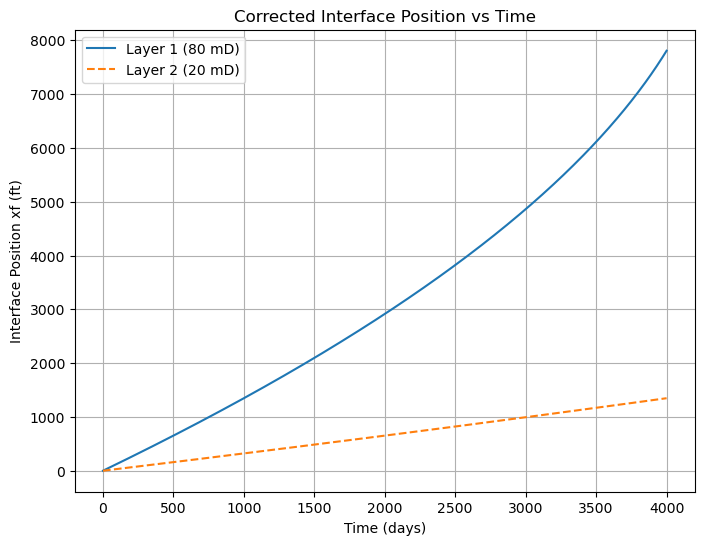

In [9]:
# Corrected Part (a): Interface Position Calculation

import numpy as np
import matplotlib.pyplot as plt

# Function to calculate interface position x_f(t)
def xf(t_days, k_layer, mu_w, mu_o, L):
    M0 = mu_o / mu_w
    phi = 0.2
    delta_S = 1.0
    delta_P = 15000 - 5000
    k_rw0 = 1.0
    conv = 0.00633

    A = (L * M0)**2
    B = 2 * (1 - M0)
    C = k_layer * k_rw0 * delta_P * conv / (phi * mu_w * delta_S)

    sqrt_term = np.sqrt(np.maximum(A + B * C * t_days, 0))
    xf_val = (-L * M0 + sqrt_term) / (B / 2)
    xf_val = np.clip(xf_val, 0, L)
    return xf_val

# Parameters
L = 10000
mu_w = 0.2
mu_o = 2.0
k1 = 80
k2 = 20
t = np.linspace(0, 4000, 400)

xf_layer1 = xf(t, k1, mu_w, mu_o, L)
xf_layer2 = xf(t, k2, mu_w, mu_o, L)

plt.figure(figsize=(8,6))
plt.plot(t, xf_layer1, label='Layer 1 (80 mD)')
plt.plot(t, xf_layer2, label='Layer 2 (20 mD)', linestyle='--')
plt.xlabel('Time (days)')
plt.ylabel('Interface Position xf (ft)')
plt.title('Corrected Interface Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

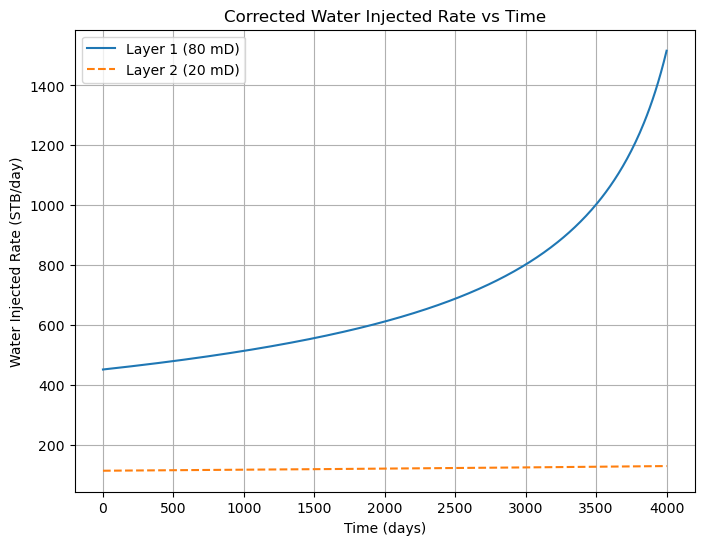

In [11]:
# Corrected Part (b): Water Injection Rate using width = 100 ft

# Function to calculate water injection rate q(t) for each layer
def rate(mu_w, mu_o, k1, k2, t_days, L, w, h):
    M0 = mu_o / mu_w
    phi = 0.2
    delta_S = 1.0
    delta_P = 15000 - 5000
    k_rw0 = 1.0
    conv = 0.00633
    bbl_per_ft3 = 1 / 5.615
    A = w * h

    def layer_rate(k_layer, xf_val):
        numerator = k_layer * k_rw0 * delta_P * A * conv
        denominator = mu_w * (xf_val + M0 * (L - xf_val))
        q = numerator / denominator
        q_bbl = q * bbl_per_ft3
        return q_bbl

    xf1 = xf(t_days, k1, mu_w, mu_o, L)
    xf2 = xf(t_days, k2, mu_w, mu_o, L)
    q1 = layer_rate(k1, xf1)
    q2 = layer_rate(k2, xf2)
    return q1, q2

# Inputs
w = 100  # Corrected width
h = 100
t = np.linspace(0, 4000, 400)
q1, q2 = rate(mu_w, mu_o, k1, k2, t, L, w, h)

plt.figure(figsize=(8,6))
plt.plot(t, q1, label='Layer 1 (80 mD)')
plt.plot(t, q2, label='Layer 2 (20 mD)', linestyle='--')
plt.xlabel('Time (days)')
plt.ylabel('Water Injected Rate (STB/day)')
plt.title('Corrected Water Injected Rate vs Time')
plt.grid(True)
plt.legend()
plt.show()

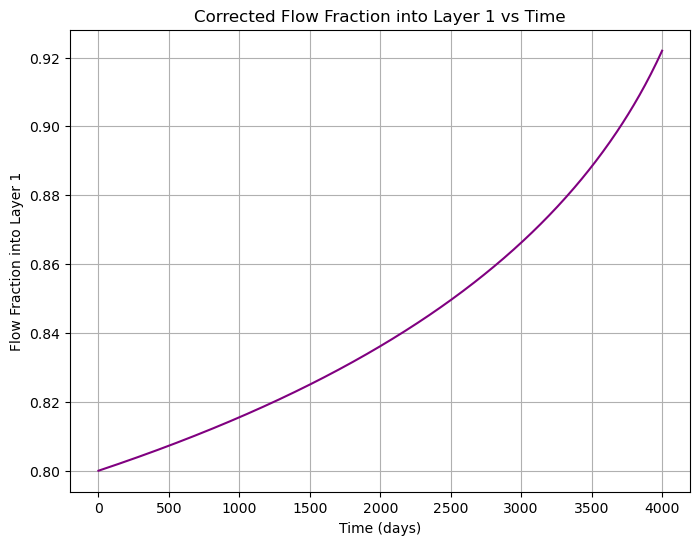

In [15]:
# Corrected Part (c): Flow Fraction into Layer 1

def flow_fraction(q1, q2):
    return q1 / (q1 + q2)

fraction_layer1 = flow_fraction(q1, q2)

plt.figure(figsize=(8,6))
plt.plot(t, fraction_layer1, color='purple')
plt.xlabel('Time (days)')
plt.ylabel('Flow Fraction into Layer 1')
plt.title('Corrected Flow Fraction into Layer 1 vs Time')
plt.grid(True)
plt.show()


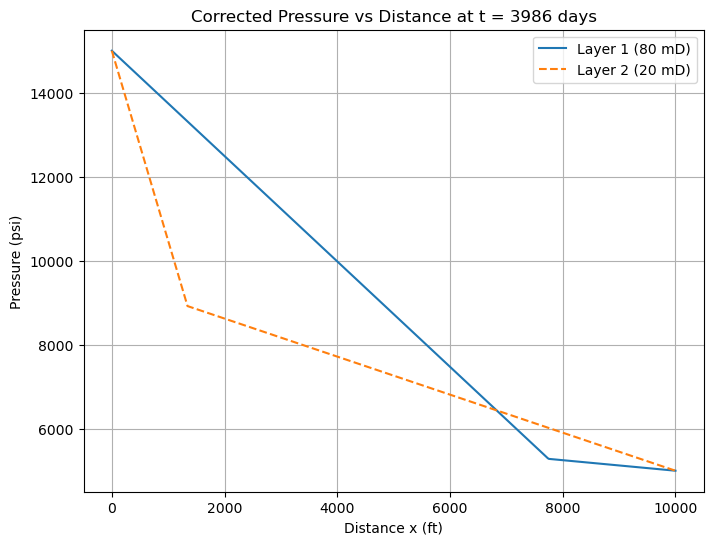

In [17]:
# Corrected Part (d): Pressure vs Distance using corrected xf values

def pressure_profile(x, xf_val, L, k_layer, mu_w, mu_o, P0, PL):
    k_rw0 = 1.0
    conv = 0.00633

    numerator = (k_rw0 * PL / (mu_w * (L - xf_val))) + (k_rw0 * P0 / (mu_o * xf_val))
    denominator = (k_rw0 / (mu_w * (L - xf_val))) + (k_rw0 / (mu_o * xf_val))
    Pf = numerator / denominator

    P = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi <= xf_val:
            P[i] = P0 - (P0 - Pf) * xi / xf_val
        else:
            P[i] = Pf - (Pf - PL) * (xi - xf_val) / (L - xf_val)
    return P

P0 = 15000
PL = 5000
t_target = 3986
xf1_3986 = xf(t_target, k1, mu_w, mu_o, L)
xf2_3986 = xf(t_target, k2, mu_w, mu_o, L)
x = np.linspace(0, L, 500)

P_layer1 = pressure_profile(x, xf1_3986, L, k1, mu_w, mu_o, P0, PL)
P_layer2 = pressure_profile(x, xf2_3986, L, k2, mu_w, mu_o, P0, PL)

plt.figure(figsize=(8,6))
plt.plot(x, P_layer1, label='Layer 1 (80 mD)')
plt.plot(x, P_layer2, label='Layer 2 (20 mD)', linestyle='--')
plt.xlabel('Distance x (ft)')
plt.ylabel('Pressure (psi)')
plt.title('Corrected Pressure vs Distance at t = 3986 days')
plt.grid(True)
plt.legend()
plt.show()


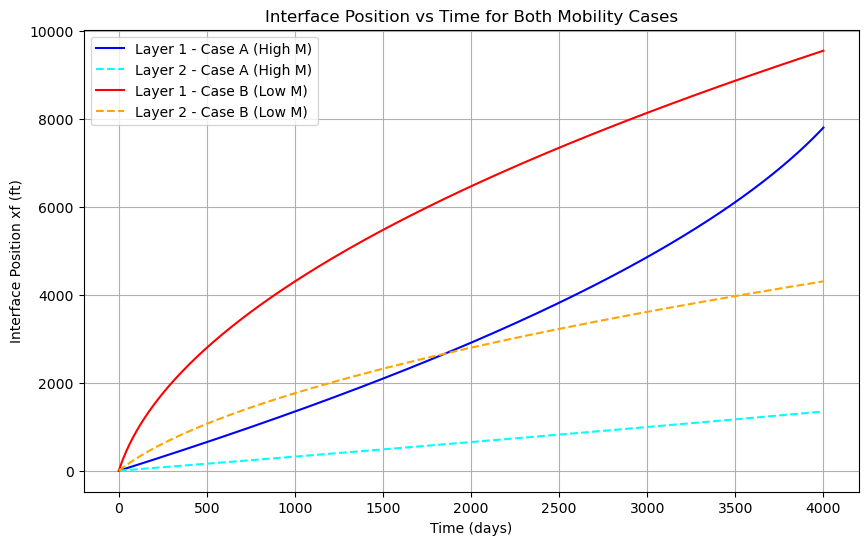

In [19]:
# Modified Part (a): Interface Position Calculation with Both Mobility Cases

import numpy as np
import matplotlib.pyplot as plt

# Function to calculate interface position x_f(t)
def xf_function(t_days, k_layer, mu_w, mu_o, L):
    M0 = mu_o / mu_w
    phi = 0.2
    delta_S = 1.0
    delta_P = 15000 - 5000
    conv = 0.00633

    A = (L * M0) ** 2
    B = 2 * (1 - M0)
    C = k_layer * delta_P * t_days * conv / (phi * mu_w * delta_S)

    radic = np.maximum(0, A + B * C)
    xf_val = (-L * M0 + np.sqrt(radic)) / (B / 2)
    xf_val = np.clip(xf_val, 0, L)
    return xf_val

# Parameters
L = 10000
k1 = 80
k2 = 20
t = np.linspace(0, 4000, 400)

# Case A: High mobility (mu_o = 2, mu_w = 0.2)
mu_wa = 0.2
mu_oa = 2.0
xf1_a = xf_function(t, k1, mu_wa, mu_oa, L)
xf2_a = xf_function(t, k2, mu_wa, mu_oa, L)

# Case B: Low mobility (mu_o = 0.2, mu_w = 2)
mu_wb = 2.0
mu_ob = 0.2
xf1_b = xf_function(t, k1, mu_wb, mu_ob, L)
xf2_b = xf_function(t, k2, mu_wb, mu_ob, L)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(t, xf1_a, label='Layer 1 - Case A (High M)', color='blue')
plt.plot(t, xf2_a, label='Layer 2 - Case A (High M)', linestyle='--', color='cyan')
plt.plot(t, xf1_b, label='Layer 1 - Case B (Low M)', color='red')
plt.plot(t, xf2_b, label='Layer 2 - Case B (Low M)', linestyle='--', color='orange')
plt.xlabel('Time (days)')
plt.ylabel('Interface Position xf (ft)')
plt.title('Interface Position vs Time for Both Mobility Cases')
plt.grid(True)
plt.legend()
plt.show()
